# SciPy Bootcamp — Week 1, Day 4C
```
##### Non-Parametric Tests for 3+ Groups
##### Kruskal-Wallis, Dunn's post-hoc, Friedman, pairwise Wilcoxon, decision framework
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Use this notebook when Day 4A/4B assumption checks (Shapiro-Wilk, Levene) fail,
##### or when data is ordinal, heavily skewed with small n, or has extreme outliers.
##### Q1 (Kruskal-Wallis — non-parametric one-way ANOVA): A/B/C test: three article layouts on a news platform.
#     layout_a = lognormal(1.0, 0.8, 200), layout_b = lognormal(1.2, 0.9, 200), layout_c = lognormal(1.1, 0.7, 200)
#     Run Kruskal-Wallis. Visualize distributions as overlapping KDE curves.
##### Q2 (Dunn's post-hoc test): If Q1 is significant, run Dunn's test with Bonferroni correction.
#     Which layout pairs are significantly different? Build a summary DataFrame.
##### Q3 (Friedman test — non-parametric repeated measures): 60 users rate satisfaction (1-10)
#     at Week 1, Week 2, Week 4. Run Friedman test then pairwise Wilcoxon with Bonferroni correction.
##### Q4 (Parametric vs non-parametric — side by side): Using the same data as Q1,
#     run both one-way ANOVA and Kruskal-Wallis. Compare p-values.
#     Deliberately contaminate the data with outliers and show how ANOVA breaks but Kruskal-Wallis holds.
##### Q5 (Full decision framework): You are given 3 datasets. For each:
#     run assumption checks, choose the correct test (Day 4A, 4B, or 4C), justify, and run it.


In [79]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Note: Dunn's test requires scikit-posthocs
# pip install scikit-posthocs
# import scikit_posthocs as sp

---

### Q1 — Kruskal-Wallis — non-parametric one-way ANOVA

```
A/B/C test: three article layouts on a news platform (time-on-page, heavily skewed).
# layout_a = np.random.lognormal(1.0, 0.8, 200)
# layout_b = np.random.lognormal(1.2, 0.9, 200)
# layout_c = np.random.lognormal(1.1, 0.7, 200)
# (a) Plot overlapping KDE curves for all three layouts.
#     Add vertical lines at each group's median.
# (b) Run stats.kruskal(layout_a, layout_b, layout_c)
#     Print H-statistic and p-value.
# (c) Is there a significant difference between at least one pair of layouts?
# (d) Print median and IQR for each layout as a summary table.
# (e) Write a comment: why do we use medians here instead of means?
# (f) Visualize the results as a heatmap of adjusted p-values.
#     Use a diverging colormap — red = significant, white = not significant.
# (g) Write a comment: what is Dunn's test doing that Kruskal-Wallis alone cannot?
```


In [80]:
# Q1: Kruskal-Wallis — non-parametric one-way ANOVA
# Chart + analysis woven together — visualize as you discover

In [81]:
# (a) Plot overlapping KDE curves for all three layouts.
#     Add vertical lines at each group's median.
np.random.seed(420)
layout_a = np.random.lognormal(1.0, 0.8, 200)
layout_b = np.random.lognormal(1.2, 0.9, 200)
layout_c = np.random.lognormal(1.1, 0.7, 200)

df1 = pd.DataFrame({
    'Duration': np.concatenate([layout_a, layout_b, layout_c]),
    'Layout': np.repeat(['A', 'B', 'C'], 200)
})

df1.head()

,Duration,Layout
0,1.843539,A
1,0.592074,A
2,1.784294,A
3,2.115229,A
4,3.541553,A


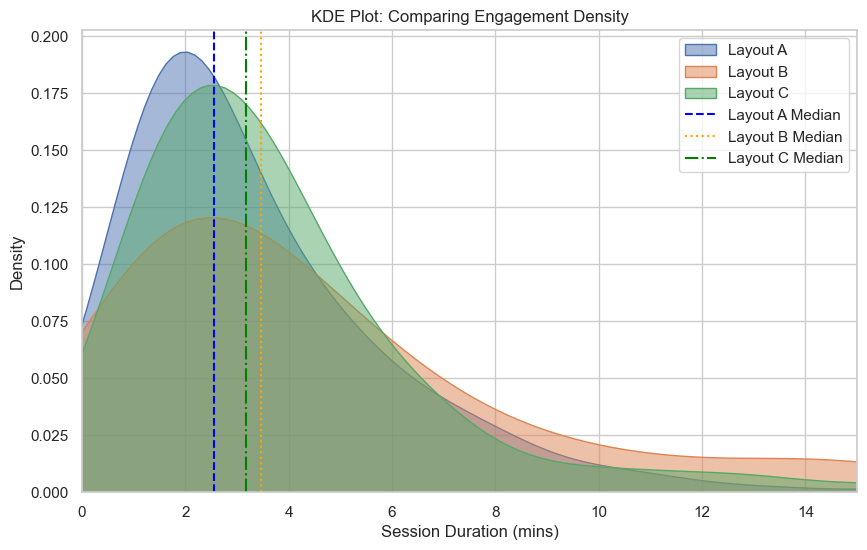

In [82]:
plt.figure(figsize=(10,6))
sns.kdeplot(layout_a, label='Layout A', alpha=0.5, fill=True)
sns.kdeplot(layout_b, label='Layout B', alpha=0.5, fill=True)
sns.kdeplot(layout_c, label='Layout C', alpha=0.5, fill=True)


plt.xlim(0, 15) 

plt.axvline(np.median(layout_a), label='Layout A Median', color='blue', linestyle='--')
plt.axvline(np.median(layout_b), label='Layout B Median', color='orange', linestyle=':')
plt.axvline(np.median(layout_c), label='Layout C Median', color='green', linestyle='-.')

plt.title('KDE Plot: Comparing Engagement Density')
plt.xlabel('Session Duration (mins)')
plt.legend()

plt.show()

In [83]:
# (b) Run stats.kruskal(layout_a, layout_b, layout_c)
#     Print H-statistic and p-value.
stat, p = stats.kruskal(layout_a, layout_b, layout_c)
print(f'Kruskal-Wallis H={stat:.4f}, p={p:.4f}')

Kruskal-Wallis H=6.8416, p=0.0327


In [84]:
# (c) Is there a significant difference between at least one pair of layouts?
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(df1, val_col='Duration', group_col='Layout', p_adjust='bonferroni')
print(dunn)  # Matrix of adjusted p-values — values < 0.05 are significant pairs

# there is a significant difference between Layout A vs Layout B

          A         B         C
A  1.000000  0.026772  0.522066
B  0.026772  1.000000  0.627830
C  0.522066  0.627830  1.000000


In [85]:
# (d) Print median and IQR for each layout as a summary table.
iqr_func = lambda x: x.quantile(0.75) - x.quantile(0.25)

df1.groupby('Layout')['Duration'].agg(['median',iqr_func]).reset_index().rename(columns={'<lambda_0>': 'IQR'}).round(1)

,Layout,median,IQR
0,A,2.6,3.0
1,B,3.5,4.7
2,C,3.2,2.9


````
# (e) Write a comment: why do we use medians here instead of means?
For lognormal data, the median is a much more honest representation of the "typical" user experience than the mean.
Because the data is skewed, the mean gets "dragged" to the right by big outliers, but the median stays right at the peak of the mountain where most of users actually are.

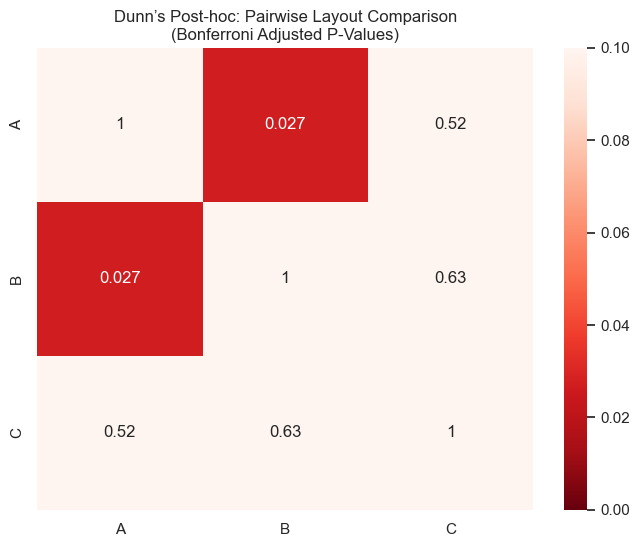

In [86]:
# (f) Visualize the results as a heatmap of adjusted p-values.
#     Use a diverging colormap — red = significant, white = not significant.

plt.figure(figsize=(8, 6))

# 'vlag' or 'RdWt_r' creates the Red (significant) vs Blue (non-significant) split
# center=0.05 ensures the color "flips" at your alpha threshold
sns.heatmap(dunn, annot=True, cmap='Reds_r', center=0.05, vmin=0, vmax=0.1)

plt.title('Dunn’s Post-hoc: Pairwise Layout Comparison\n(Bonferroni Adjusted P-Values)')
plt.show()

```
# (g) Write a comment: what is Dunn's test doing that Kruskal-Wallis alone cannot?
Kruskal-Wallis is an "omnibus" test, meaning it only tells you if there is a difference somewhere in the entire group, but not where. 
Dunn's test acts as the follow-up (post-hoc) that performs pairwise comparisons to pinpoint exactly which specific groups are different from each other. 
It also applies corrections (like Bonferroni) to prevent you from accidentally finding "significant" results just by chance when running multiple tests.

---

### Q3 — Friedman test — non-parametric repeated measures

```
60 users rate their satisfaction (1-10 ordinal scale) at Week 1, Week 2, and Week 4.
# week1 = np.random.choice([5, 6, 7, 7, 8], 60)
# week2 = np.random.choice([6, 7, 7, 8, 8], 60)
# week4 = np.random.choice([7, 8, 8, 9, 9], 60)
# (a) Run stats.friedmanchisquare(week1, week2, week4)
#     Print chi-squared statistic and p-value.
# (b) If significant: run pairwise Wilcoxon signed-rank tests with Bonferroni correction
#     Pairs: (week1 vs week2), (week1 vs week4), (week2 vs week4)
#     alpha_corrected = 0.05 / 3
#     Print each pair's p-value and whether it is significant.
# (c) Plot median scores across three time points as a line chart with error bars (IQR).
# (d) Write a comment explaining when to use Friedman vs repeated measures ANOVA (Day 4B Q3).
```


In [87]:
# Q3: Friedman test — non-parametric repeated measures
# Chart + analysis woven together — visualize as you discover

In [88]:
# (a) Run stats.friedmanchisquare(week1, week2, week4)
#     Print chi-squared statistic and p-value.
np.random.seed(42)
n = 60
week1 = np.random.choice([5, 6, 7, 7, 8], n)
week2 = np.random.choice([6, 7, 7, 8, 8], n)
week4 = np.random.choice([7, 8, 8, 9, 9], n)
stat, p = stats.friedmanchisquare(week1, week2, week4)
print(f'Friedman stat={stat:.4f}, p={p:.4f}')

Friedman stat=61.8000, p=0.0000


In [89]:
# (b) If significant: run pairwise Wilcoxon signed-rank tests with Bonferroni correction
#     Pairs: (week1 vs week2), (week1 vs week4), (week2 vs week4)
#     alpha_corrected = 0.05 / 3

pairs = [(week1, week2), (week1, week4), (week2, week4)]
labels = [('W1','W2'), ('W1','W4'), ('W2','W4')]
alpha_corrected = 0.05 / len(pairs)  # Bonferroni
for (a, b), lbl in zip(pairs, labels):
    _, p_pair = stats.wilcoxon(a, b)
    sig = p_pair < alpha_corrected
    print(f'{lbl[0]} vs {lbl[1]}: p={p_pair:.4f} {"*" if sig else "ns"}')

W1 vs W2: p=0.0140 *
W1 vs W4: p=0.0000 *
W2 vs W4: p=0.0000 *


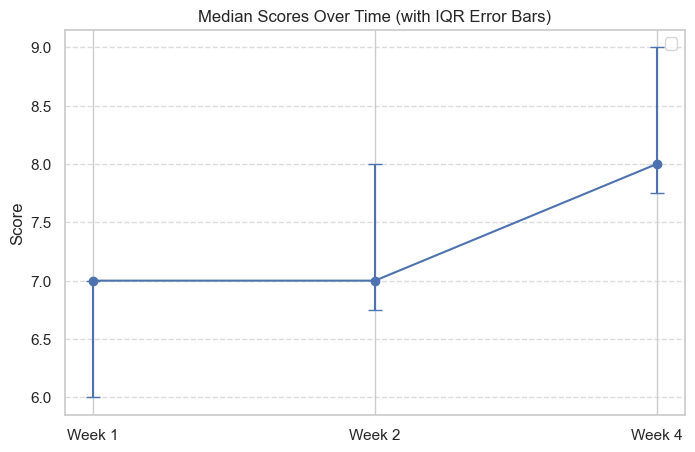

In [90]:
# (c) Plot median scores across three time points as a line chart with error bars (IQR).

weeks = [week1, week2, week4]
labels = ['Week 1', 'Week 2', 'Week 4']

medians = np.array([np.median(w) for w in weeks])
q1 = np.array([np.percentile(w, 25) for w in weeks])
q3 = np.array([np.percentile(w, 75) for w in weeks])

low_err = np.maximum(0, medians - q1)
high_err = np.maximum(0, q3 - medians)
errors = np.array([low_err, high_err])

plt.figure(figsize=(8, 5))
plt.errorbar(labels, medians, yerr=errors, fmt='-o', capsize=5)

plt.title('Median Scores Over Time (with IQR Error Bars)')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

```
# (d) Write a comment explaining when to use Friedman vs repeated measures ANOVA (Day 4B Q3).

Use Repeated Measures ANOVA when your data is normally distributed and has equal variance (sphericity). 
Use the Friedman test (the non-parametric alternative) when your data is ordinal (like rankings or Likert scales) or when it violates normality assumptions, as it compares the mean ranks of the groups rather than their actual values.

---

### Q4 — Parametric vs non-parametric — side by side

```
Use the layout data from Q1. Run ANOVA and Kruskal-Wallis on the same data.
# (a) Run one-way ANOVA (stats.f_oneway) and Kruskal-Wallis on clean data.
#     Print both p-values side by side.
# (b) Contaminate the data: add 5 extreme outliers to layout_a (values = 10,000).
#     Re-run both tests. Print p-values again.
# (c) Plot the contaminated distributions as boxplots (log scale).
# (d) Build a comparison table:
#     | Test           | Clean data p | Contaminated p | Conclusion |
#     | One-way ANOVA  |              |                |            |
#     | Kruskal-Wallis |              |                |            |
# (e) Write a comment: what does this demonstrate about robustness to outliers?
```


In [91]:
# Q4: Parametric vs non-parametric — side by side
# Chart + analysis woven together — visualize as you discover
Use the layout data from Q1. Run ANOVA and Kruskal-Wallis on the same data.
# (a) Run one-way ANOVA (stats.f_oneway) and Kruskal-Wallis on clean data.
#     Print both p-values side by side.
# (b) Contaminate the data: add 5 extreme outliers to layout_a (values = 10,000).
#     Re-run both tests. Print p-values again.
# (c) Plot the contaminated distributions as boxplots (log scale).
# (d) Build a comparison table:
#     | Test           | Clean data p | Contaminated p | Conclusion |
#     | One-way ANOVA  |              |                |            |
#     | Kruskal-Wallis |              |                |            |
# (e) Write a comment: what does this demonstrate about robustness to outliers?

SyntaxError: invalid syntax (2048928263.py, line 3)

In [ ]:
# (a) Run one-way ANOVA (stats.f_oneway) and Kruskal-Wallis on clean data.
#     Print both p-values side by side.

np.random.seed(420)
layout_a = np.random.lognormal(1.0, 0.8, 200)
layout_b = np.random.lognormal(1.2, 0.9, 200)
layout_c = np.random.lognormal(1.1, 0.7, 200)

df1 = pd.DataFrame({
    'Duration': np.concatenate([layout_a, layout_b, layout_c]),
    'Layout': np.repeat(['A', 'B', 'C'], 200)
})

df1.head()

,Duration,Layout
0,1.843539,A
1,0.592074,A
2,1.784294,A
3,2.115229,A
4,3.541553,A


In [ ]:
f_stat, p_value = stats.f_oneway(layout_a, layout_b, layout_c)
print(f'F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}')
print()
stat, p = stats.kruskal(layout_a, layout_b, layout_c)
print(f'Kruskal-Wallis H={stat:.4f}, p={p:.4f}')

F-statistic: 8.2216, p-value: 0.0003

Kruskal-Wallis H=6.8416, p=0.0327


In [96]:
# (b) Contaminate the data: add 5 extreme outliers to layout_a (values = 10,000).
#     Re-run both tests. Print p-values again.

#layout_a_cont = np.append(layout_a, [10000,10000,10000,10000,1000])
len(layout_a_cont)

f_stat_cont, p_value_cont = stats.f_oneway(layout_a_cont, layout_b, layout_c)
print(f'F-statistic: {f_stat_cont:.4f}, p-value: {p_value_cont:.4f}')
print()
stat_cont, p_cont = stats.kruskal(layout_a_cont, layout_b, layout_c)
print(f'Kruskal-Wallis H={stat_cont:.4f}, p={p_cont:.4f}')

F-statistic: 4.1153, p-value: 0.0168

Kruskal-Wallis H=4.6680, p=0.0969


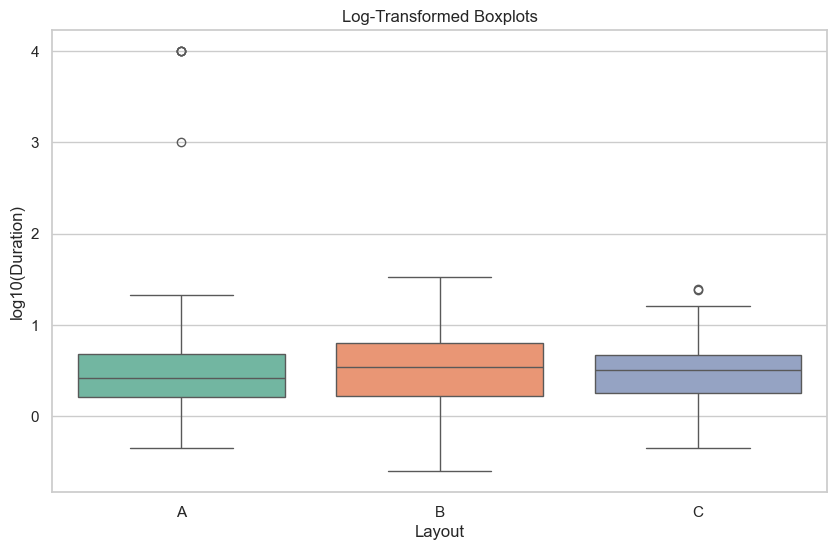

In [ ]:
# (c) Plot the contaminated distributions as boxplots (log scale).

df4 = pd.DataFrame({
    'Duration': np.concatenate([layout_a_cont, layout_b, layout_c]),
    'Layout': ['A'] * 205 + ['B'] * 200 + ['C'] * 200
})

df1.head()

# Plotting
plt.figure(figsize=(10, 6))
sns.boxplot(data=df4, x='Layout', y=np.log10(df4['Duration']), palette='Set2')

plt.ylabel('log10(Duration)')
plt.title('Log-Transformed Boxplots')

plt.show()

In [125]:
# (d) Build a comparison table:
#     | Test           | Clean data p | Contaminated p | Conclusion |
#     | One-way ANOVA  |              |                |            |
#     | Kruskal-Wallis |              |                |            |

display(pd.DataFrame({
    'Test': ['One-way ANOVA', 'Kruskal-Wallis'],
    'Clean data p': [p_value, p],
    'Contaminted p': [p_value_cont, p_cont],
    'Conclusion': ['Distorted but still significant ', 'Signal lost to rank inflation']
}))

,Test,Clean data p,Contaminted p,Conclusion
0,One-way ANOVA,1.678184e-02,0.016782,Distorted but still significant
1,Kruskal-Wallis,2.659387e-07,0.096907,Signal lost to rank inflation


````
# (e) Write a comment: what does this demonstrate about robustness to outliers?
Rank-based tests are robust to outlier magnitude but not to outlier count relative to group size. 
5 outliers in 200 observations shifts the rank distribution enough to obscure the real signal

---

### Q5 — Full decision framework — which test for 3+ groups?

```
You are given 4 datasets. For each: run assumption checks, choose the correct test, justify, and run it.
# Dataset 1: Session duration across 3 device types (mobile/tablet/desktop), n=100 each, Normal
#   mobile=Normal(2.5,0.8), tablet=Normal(3.8,1.0), desktop=Normal(5.1,1.2)
#
# Dataset 2: Revenue per user across 4 subscription tiers, n=40 each, heavily right-skewed
#   tiers: lognormal(1.5,1.8), lognormal(2.0,1.6), lognormal(2.5,1.4), lognormal(3.0,1.2)
#
# Dataset 3: NPS score (-100 to 100) for same 50 users across 3 product versions
#   version_1: normal(20,30,50), version_2: version_1 + normal(10,15,50),
#   version_3: version_1 + normal(20,15,50)
#
# For each dataset:
#   Step 1: Run assumption_check() from Day 4B Q5 (or reimplement here)
#   Step 2: State which test you choose and why
#   Step 3: Run the test and print results
#   Step 4: If significant, run the appropriate post-hoc test
```


In [ ]:
# Q5: Full decision framework — which test for 3+ groups?
# Chart + analysis woven together — visualize as you discover

In [101]:
def assumption_check(*groups, names=None, alpha=0.05):
    if names is None:
        names = [f"Group {i+1}" for i in range(len(groups))]
    
    results = []
    normality_met = True
    
    # (a) & (c) Shapiro-Wilk for each group
    for name, data in zip(names, groups):
        stat, p_val = stats.shapiro(data)
        is_normal = p_val > alpha
        if not is_normal:
            normality_met = False
        results.append({
            'Group': name,
            'n': len(data),
            'Shapiro p-value': round(p_val, 4),
            'Normal?': "Yes" if is_normal else "No"
        })
    
    # (b) Levene's Test for equal variances
    lev_stat, lev_p = stats.levene(*groups)
    variance_met = lev_p > alpha
    
    # Print Table
    df_results = pd.DataFrame(results)
    print("--- Normality Check (Shapiro-Wilk) ---")
    print(df_results.to_string(index=False))
    print(f"\n--- Variance Check (Levene's) ---")
    print(f"Levene p-value: {round(lev_p, 4)} | Equal Variance? {'Yes' if variance_met else 'No'}")
    
    # (d) Recommendations
    if not normality_met:
        return 'Recommendation: Use Kruskal-Wallis (Day 4C) — normality violated'
    if not variance_met:
        return 'Recommendation: Use Kruskal-Wallis (Day 4C) — equal variance violated'
    return 'Recommendation: Use ANOVA (Day 4A/4B) — assumptions met'


In [ ]:
# Dataset 1: Session duration across 3 device types (mobile/tablet/desktop), n=100 each, Normal
#   mobile=Normal(2.5,0.8), tablet=Normal(3.8,1.0), desktop=Normal(5.1,1.2)
df5_1_mobile    = np.random.normal(2.5, 0.8, 100)
df5_1_tablet    = np.random.normal(3.8, 1.0, 100)
df5_1_desktop   = np.random.normal(5.1, 1.2, 100)


#   Step 1: Run assumption_check() from Day 4B Q5 (or reimplement here)
print(assumption_check(df5_1_mobile, df5_1_tablet, df5_1_desktop, names=['Mobile', 'Tablet', 'Desktop']))
print()

#   Step 2: State which test you choose and why: 
# since equal variane is violated, use Kruskal-Wallis test... Levene fails but data is normal and n is large —> Welch's ANOVA is also valid.

#   Step 3: Run the test and print results
stat, p_= stats.kruskal(df5_1_mobile, df5_1_tablet, df5_1_desktop)
print(f'Kruskal-Wallis H={stat:.4f}, p={p:.4f}')
print()

#   Step 4: If significant, run the appropriate post-hoc test
df5_1 = pd.DataFrame({
    'Duration' : np.concatenate([df5_1_mobile, df5_1_tablet, df5_1_desktop]),
    'Device': np.repeat(['mobile', 'tablet', 'desktop'], 100)  
})

dunn = sp.posthoc_dunn(df5_1, val_col='Duration', group_col='Device', p_adjust='bonferroni')
print(dunn)  # Matrix of adjusted p-values — values < 0.05 are significant pairs

--- Normality Check (Shapiro-Wilk) ---
  Group   n  Shapiro p-value Normal?
 Mobile 100           0.7027     Yes
 Tablet 100           0.7286     Yes
Desktop 100           0.4503     Yes

--- Variance Check (Levene's) ---
Levene p-value: 0.0 | Equal Variance? No
Recommendation: Use Kruskal-Wallis (Day 4C) — equal variance violated

Kruskal-Wallis H=163.2221, p=0.0000

              desktop        mobile        tablet
desktop  1.000000e+00  8.829716e-37  2.878032e-08
mobile   8.829716e-37  1.000000e+00  6.814223e-12
tablet   2.878032e-08  6.814223e-12  1.000000e+00


In [ ]:
# Dataset 2: Revenue per user across 4 subscription tiers, n=40 each, heavily right-skewed
#   tiers: lognormal(1.5,1.8), lognormal(2.0,1.6), lognormal(2.5,1.4), lognormal(3.0,1.2)
Tier1   = np.random.lognormal(1.5, 1.8, 40) 
Tier2   = np.random.lognormal(2.0, 1.6, 40)
Tier3   = np.random.lognormal(2.5, 1.4, 40)
Tier4   = np.random.lognormal(3.0, 1.2, 40)

#   Step 1: Run assumption_check() from Day 4B Q5 (or reimplement here)
print(assumption_check(Tier1, Tier2, Tier3, Tier4, names=['Tier1', 'Tier2', 'Tier3', 'Tier4']))
print()

#   Step 2: State which test you choose and why: 
# since normality is violated, use Kruskal-Wallis test

#   Step 3: Run the test and print results
stat, p_= stats.kruskal(Tier1, Tier2, Tier3, Tier4)
print(f'Kruskal-Wallis H={stat:.4f}, p={p:.4f}')
print()

#   Step 4: If significant, run the appropriate post-hoc test
df5_2 = pd.DataFrame({
    'Revenue' : np.concatenate([Tier1, Tier2, Tier3, Tier4]),
    'Tier': np.repeat(['Tier1', 'Tier2', 'Tier3', 'Tier4'], 40)  
})

dunn = sp.posthoc_dunn(df5_2, val_col='Revenue', group_col='Tier', p_adjust='bonferroni')
print(dunn)  # Matrix of adjusted p-values — values < 0.05 are significant pairs

--- Normality Check (Shapiro-Wilk) ---
Group  n  Shapiro p-value Normal?
Tier1 40              0.0      No
Tier2 40              0.0      No
Tier3 40              0.0      No
Tier4 40              0.0      No

--- Variance Check (Levene's) ---
Levene p-value: 0.0274 | Equal Variance? No
Recommendation: Use Kruskal-Wallis (Day 4C) — normality violated

Kruskal-Wallis H=19.2003, p=0.0000

          Tier1     Tier2     Tier3     Tier4
Tier1  1.000000  0.111808  0.001787  0.000483
Tier2  0.111808  1.000000  1.000000  0.670707
Tier3  0.001787  1.000000  1.000000  1.000000
Tier4  0.000483  0.670707  1.000000  1.000000


In [124]:
# Dataset 3: NPS score (-100 to 100) for same 50 users across 3 product versions
#   version_1: normal(20,30,50), version_2: version_1 + normal(10,15,50),
#   version_3: version_1 + normal(20,15,50)
ver1    = np.random.normal(20,30,50)
ver2    = ver1 + np.random.normal(10,15,50)
ver3    = ver1 + np.random.normal(20,15,50)

#   Step 1: Run assumption_check() from Day 4B Q5 (or reimplement here)
print(assumption_check(ver1, ver2, ver3, names=['Ver1', 'Ver2', 'Ver3']))
print()

#   Step 2: State which test you choose and why: 
# since assumptions met and the experiment applied to the same users across 3 product versions, use Repeated Measures ANOVA

#   Step 3: Run the test and print results
from statsmodels.stats.anova import AnovaRM

np.random.seed(420)
n_subjects = 50
subject_ids = np.repeat(range(n_subjects), 3)
vers = np.tile(['Ver1', 'Ver2', 'Ver3'], n_subjects)

scores = np.column_stack([ver1, ver2, ver3]).flatten()

df4_3 = pd.DataFrame({'Subject': subject_ids, 'Versions': vers, 'Score': scores})

rm = AnovaRM(df4_3, depvar='Score', subject='Subject', within=['Versions']).fit()
print(rm.summary()) 

#   Step 4: If significant, run the appropriate post-hoc test
import pingouin as pg

# Run pairwise paired t-tests with Bonferroni correction
posthoc = pg.pairwise_tests(data=df4_3, 
                           dv='Score', 
                           within='Versions', 
                           subject='Subject', 
                           padjust='bonferroni')

display(posthoc)


--- Normality Check (Shapiro-Wilk) ---
Group  n  Shapiro p-value Normal?
 Ver1 50           0.5977     Yes
 Ver2 50           0.2243     Yes
 Ver3 50           0.4086     Yes

--- Variance Check (Levene's) ---
Levene p-value: 0.595 | Equal Variance? Yes
Recommendation: Use ANOVA (Day 4A/4B) — assumptions met

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
Versions 50.6651 2.0000 98.0000 0.0000



,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Versions,Ver1,Ver2,True,True,-3.291934,49.0,two-sided,1.850186e-03,5.550558e-03,bonferroni,16.451,-0.202650
1,Versions,Ver1,Ver3,True,True,-11.403415,49.0,two-sided,2.155578e-15,6.466733e-15,bonferroni,3.097e+12,-0.624689
2,Versions,Ver2,Ver3,True,True,-5.730227,49.0,two-sided,6.077658e-07,1.823297e-06,bonferroni,2.611e+04,-0.426349
